# **Data Mining I | <span style="color: steelblue;">Segmentation</span>**

## A Clustering-Based Exploration of WorkplaceAbsence Patterns

*Group 07*

*Group members* : Francisco Gomes (20221810), Margarida Marchão (20221901), Pedro Coimbras (20211573) and Marta Alves (20221890).

In [21]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px
from pylab import rcParams
rcParams['figure.figsize'] = 30, 15
import umap

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
#from tqdm.notebook import tqdm, trange
#tqdm.pandas(desc="Progress")

import warnings
from modeling_pipeline import(
    compare_cluster_solutions,
    calculate_group_means,
    create_dendrogram,
    visualize_inertia_silhouette,
    plot_dimensionality_reduction_results,
    plot_cluster_by_coordinates,
    plot_r2_hc
)
warnings.filterwarnings('ignore', category = FutureWarning)
pd.set_option('display.max_columns', None)

In [22]:
worker = pd.read_csv('Processed Absenteeism Dataset.csv')
display(worker.head())

,Age,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Disciplinary failure,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Absenteeism time in hours,Reason for absence,Month of absence,Day of the week,Seasons,Education,bmi_category
0,33,289,36,13.0,32.0,0,2,1,0,1,90.0,172,4,Unjustified absence,July,Tuesday,Summer,High School,Obesity Class I
1,50,118,13,18.0,15.0,1,1,1,0,0,98.0,178,0,Unspecified,July,Tuesday,Spring,High School,Obesity Class I
2,38,179,51,18.0,27.0,0,0,1,0,0,89.0,170,2,Medical consultation,July,Wednesday,Summer,High School,Obesity Class I
3,39,279,5,14.0,26.0,0,2,1,1,0,68.0,168,4,Diseases of the eye and adnexa,July,Thursday,Spring,High School,Healthy Weight
4,33,289,36,13.0,32.0,0,2,1,0,1,90.0,172,2,Medical consultation,July,Thursday,Summer,High School,Obesity Class I


In [23]:
# columns that are still categorical (object dtype)
cat_cols = ['Reason for absence', 'Month of absence', 'Day of the week', 'Seasons','Education','bmi_category']

# create dummy variables for *only* these columns
worker = pd.get_dummies(worker, columns=cat_cols, drop_first=True)


In [24]:
worker.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 65 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Age                                                                                      800 non-null    int64  
 1   Transportation expense                                                                   800 non-null    int64  
 2   Distance from Residence to Work                                                          800 non-null    int64  
 3   Service time                                                                             800 non-null    float64
 4   Years until retirement                                                                   800 non-null    float64
 5   Disciplinary failure                                            

# **Scaling**

In [25]:
# No scaling
worker_no_scl = worker.copy()
# StandardScaler
worker_st_scl = pd.DataFrame(StandardScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)
# MinMaxScaler
worker_mm_scl = pd.DataFrame(MinMaxScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)
# RobustScaler
worker_rb_scl = pd.DataFrame(RobustScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)

# **Clustering**

In the notebook, the cluster analysis is grouped by data inputs: no scaling,standard scaler, minmax scaler, and robust scaler. In each group, the following methods of clustering were used and are presented in this order:

1. KMeans
2. Ward (Hierarchical)

Given that the Ward method consistently outperforms the other methods in terms of the R2 metric across all cluster numbers, it is justifiable to focus on analyzing the Ward method for hierarchical clustering in this context. The Ward method provides a superior explanation of the variance within the data, making it the most reliable choice for this analysis.

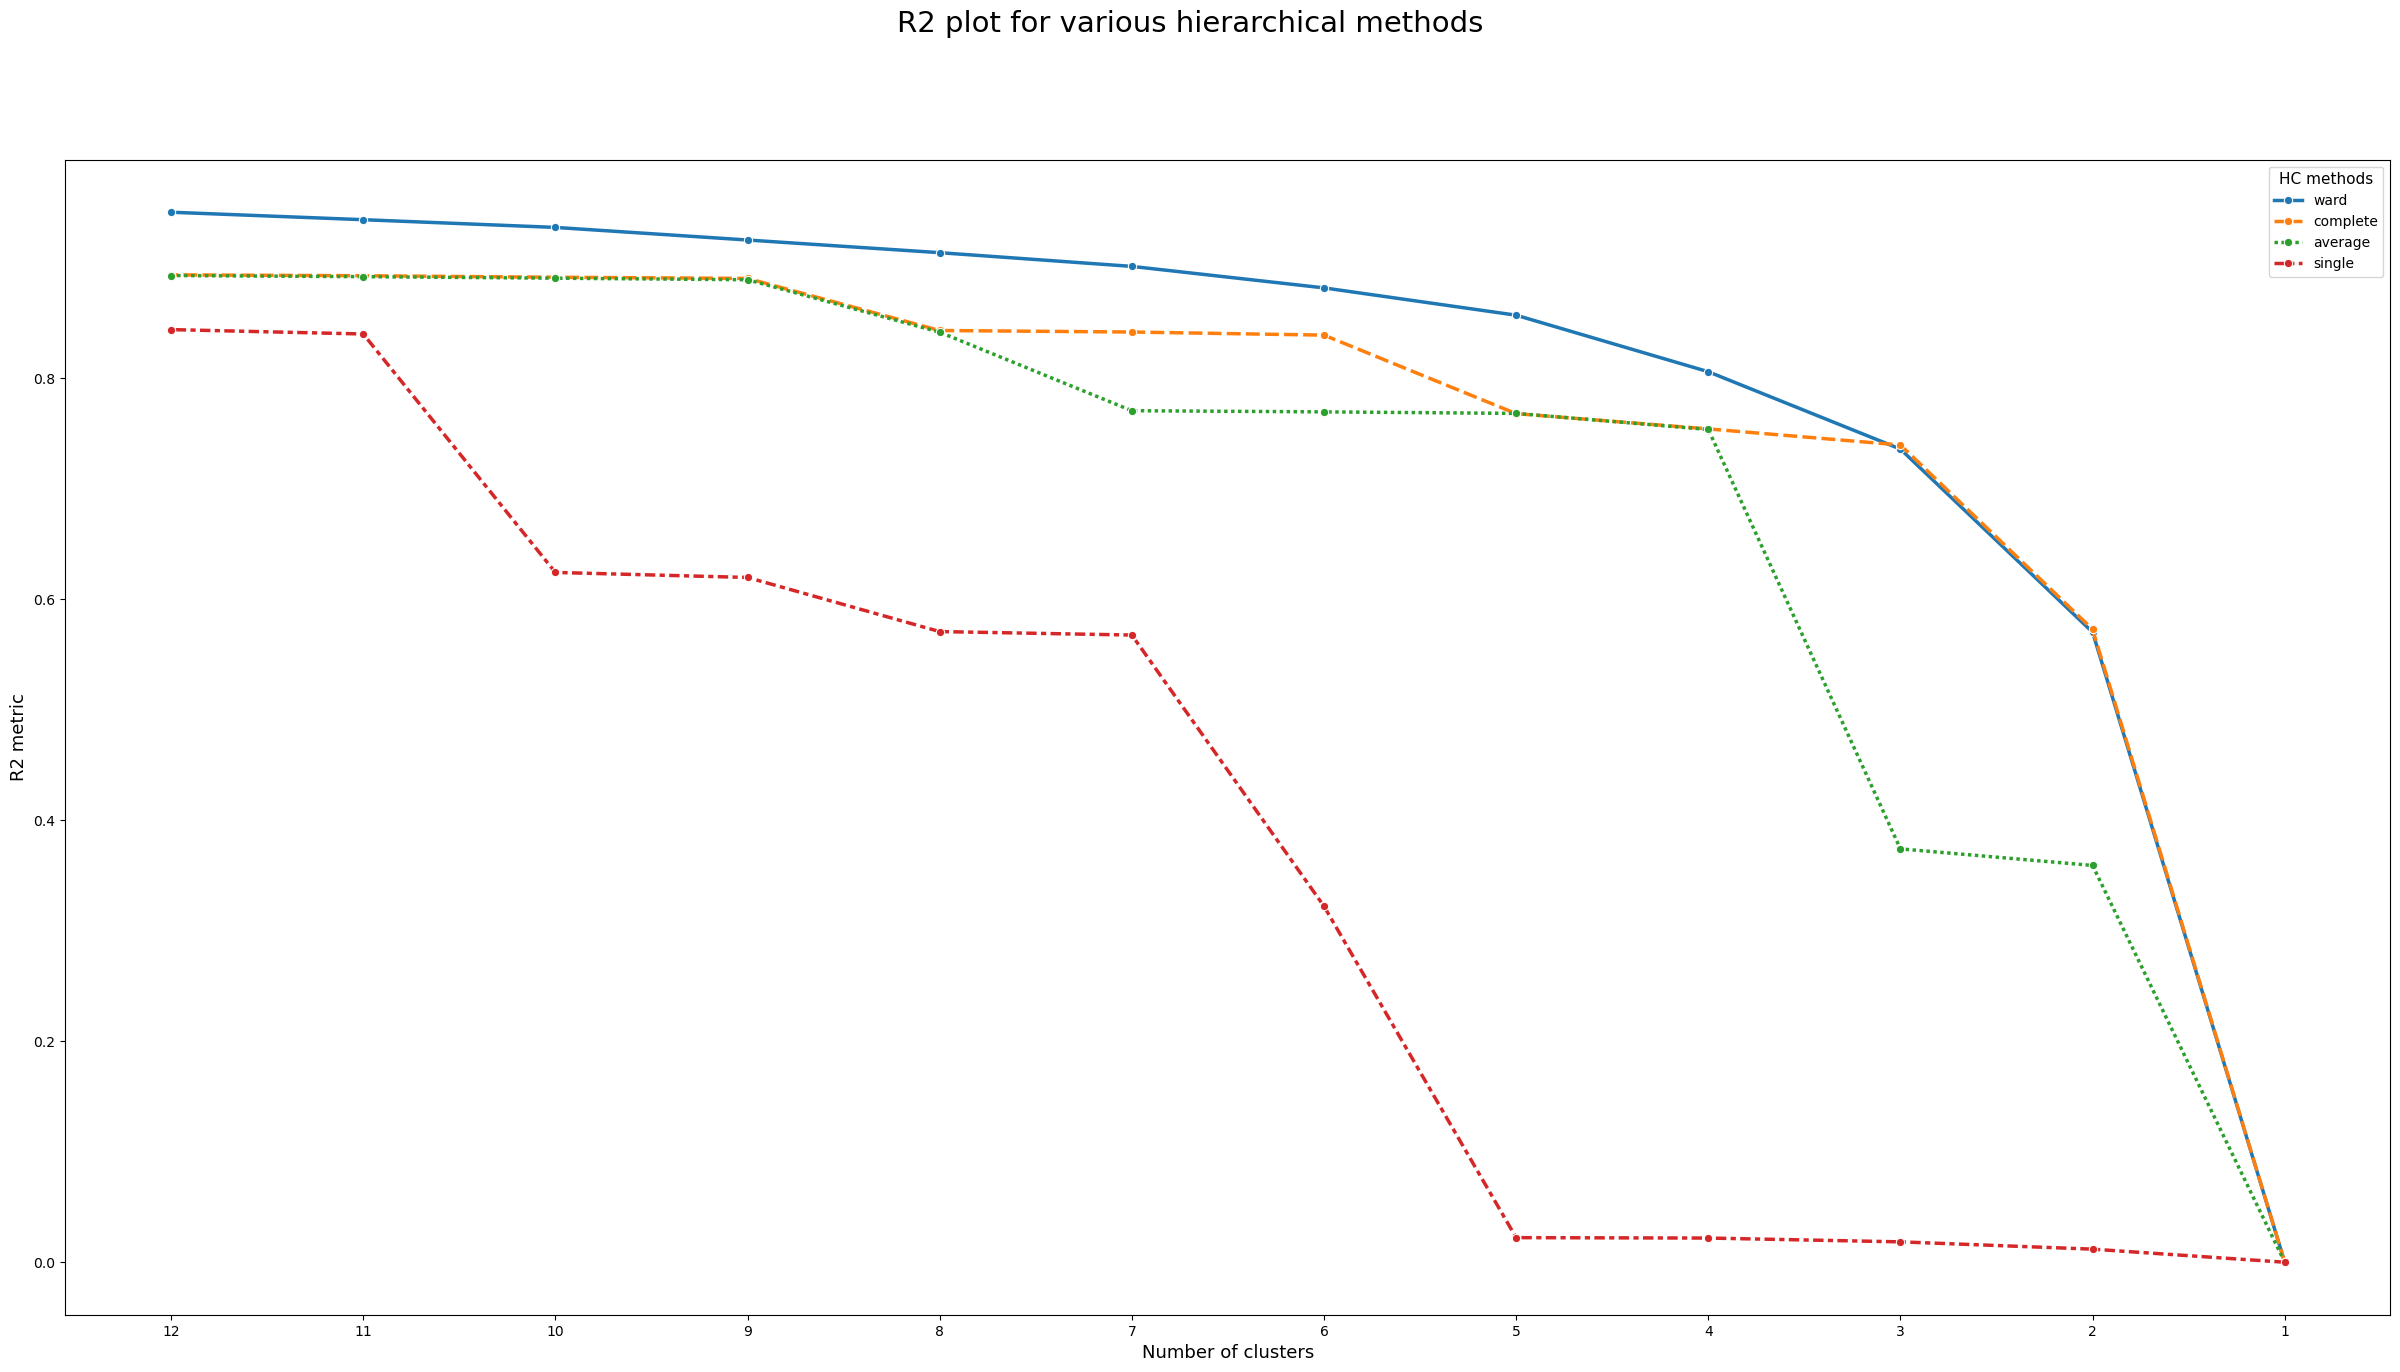

In [26]:
plot_r2_hc(worker_no_scl, max_nclus=12)

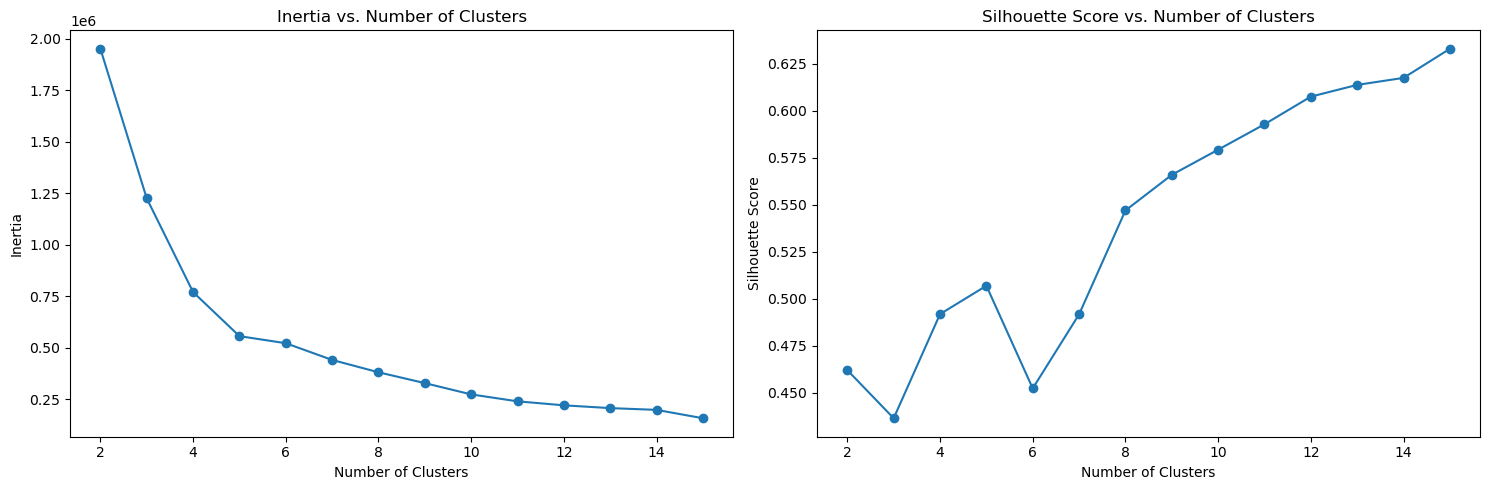

In [27]:
visualize_inertia_silhouette(worker_no_scl)

In [28]:
kmeans = KMeans(n_clusters = 6, random_state = 0).fit(worker_no_scl)
worker['no_kmeans6'] = kmeans.predict(worker_no_scl)

kmeans = KMeans(n_clusters = 8, random_state = 0).fit(worker_no_scl)
worker['no_kmeans8'] = kmeans.predict(worker_no_scl)

In [29]:
compare_cluster_solutions(worker, 'no_kmeans6', 'no_kmeans8')

,no_kmeans8 Cluster 0,no_kmeans8 Cluster 1,no_kmeans8 Cluster 2,no_kmeans8 Cluster 3,no_kmeans8 Cluster 4,no_kmeans8 Cluster 5,no_kmeans8 Cluster 6,no_kmeans8 Cluster 7
no_kmeans6 Cluster 0,53,0,0,0,101,0,1,0
no_kmeans6 Cluster 1,0,96,0,0,0,0,1,0
no_kmeans6 Cluster 2,0,0,72,0,0,0,0,0
no_kmeans6 Cluster 3,0,0,0,209,0,0,0,0
no_kmeans6 Cluster 4,0,0,0,0,0,0,1,38
no_kmeans6 Cluster 5,119,0,0,0,0,105,4,0


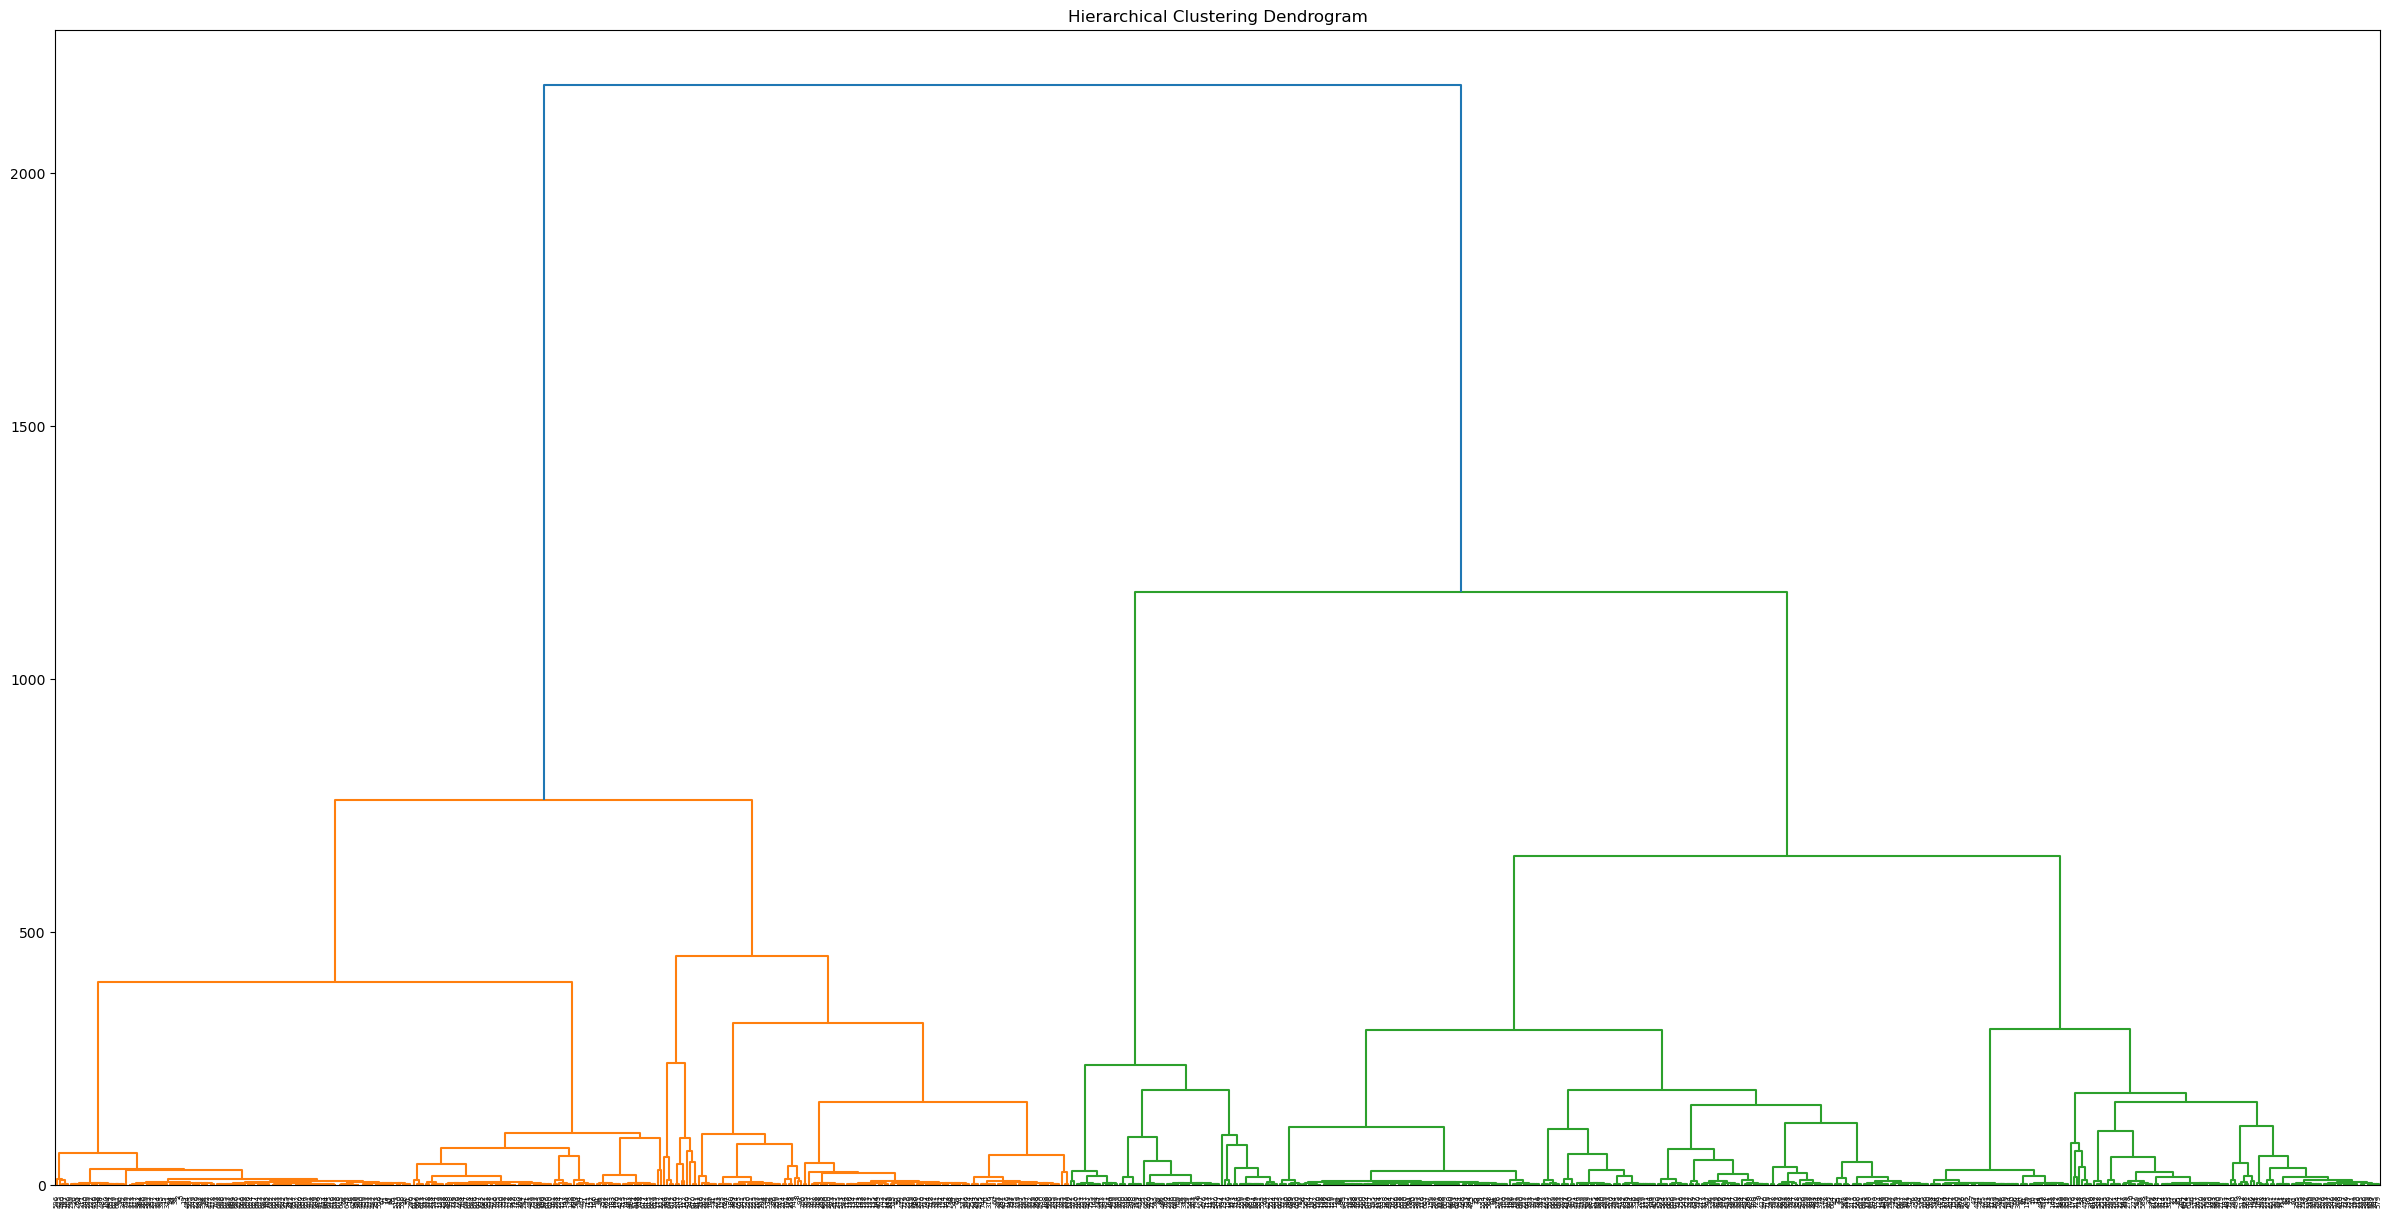

In [30]:
create_dendrogram(worker_no_scl, 'ward')

In [46]:
worker['no_ward5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(worker_no_scl)

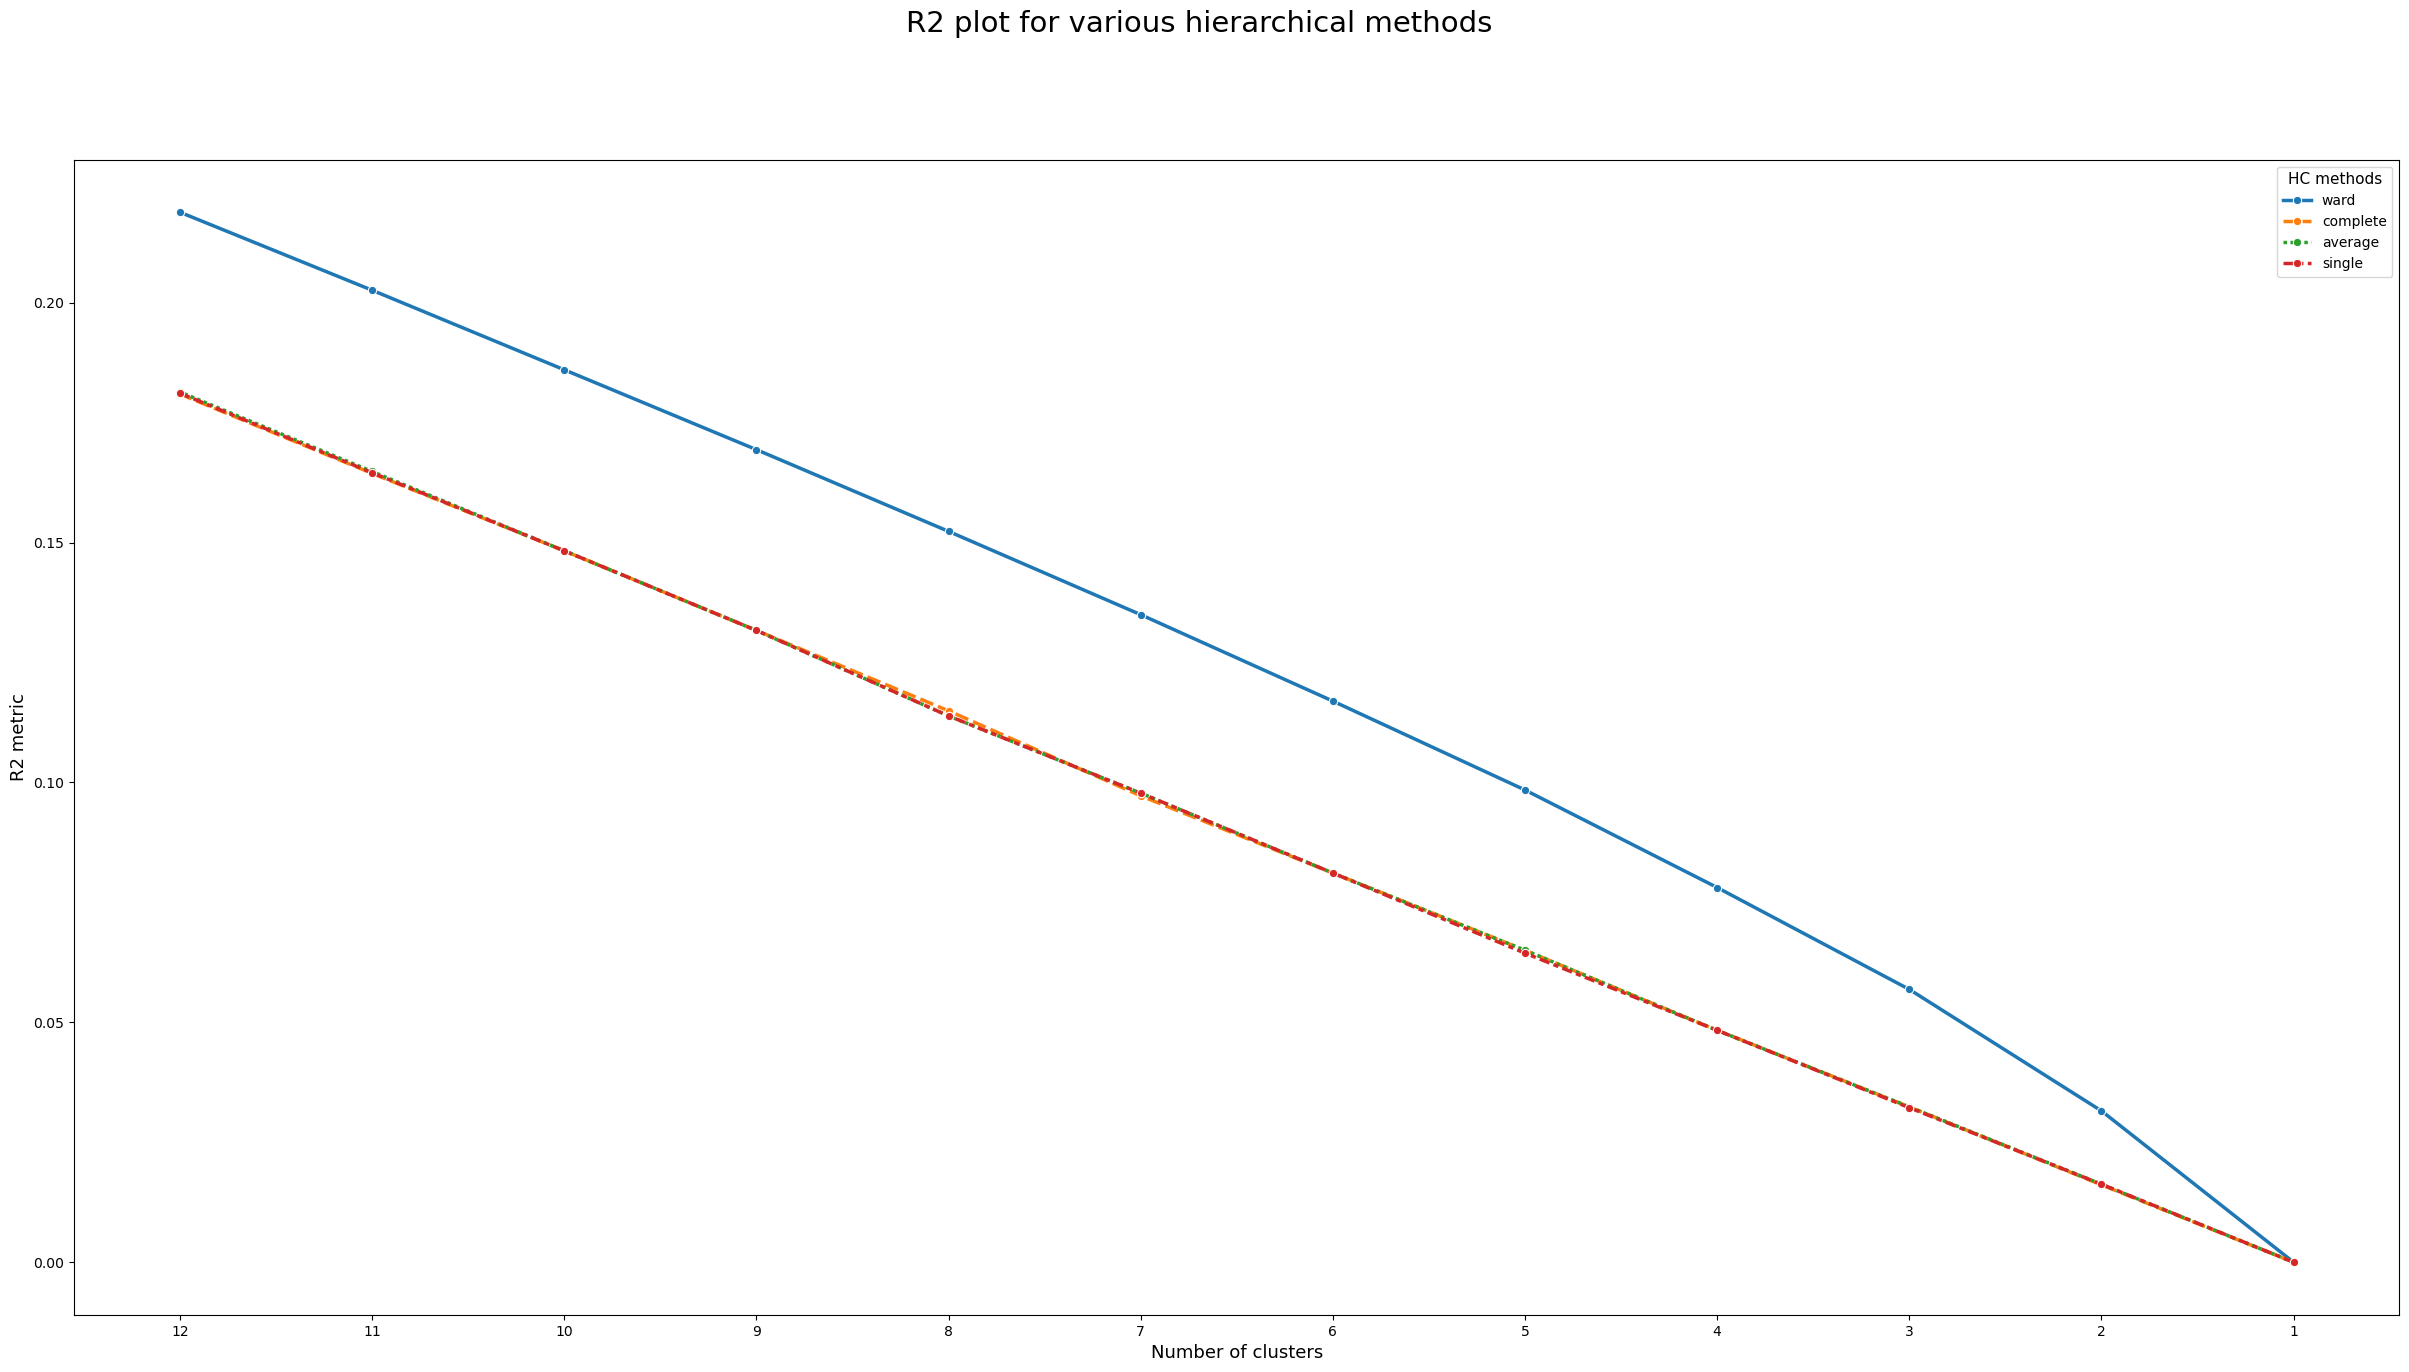

In [31]:
plot_r2_hc(worker_st_scl, max_nclus=12)

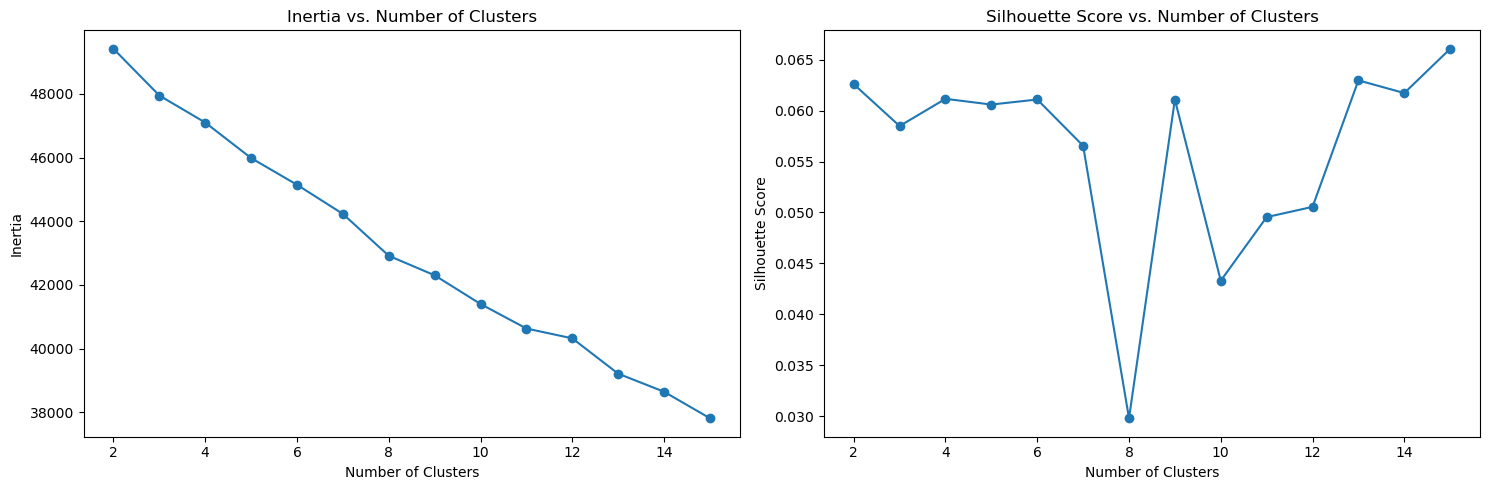

In [32]:
visualize_inertia_silhouette(worker_st_scl)

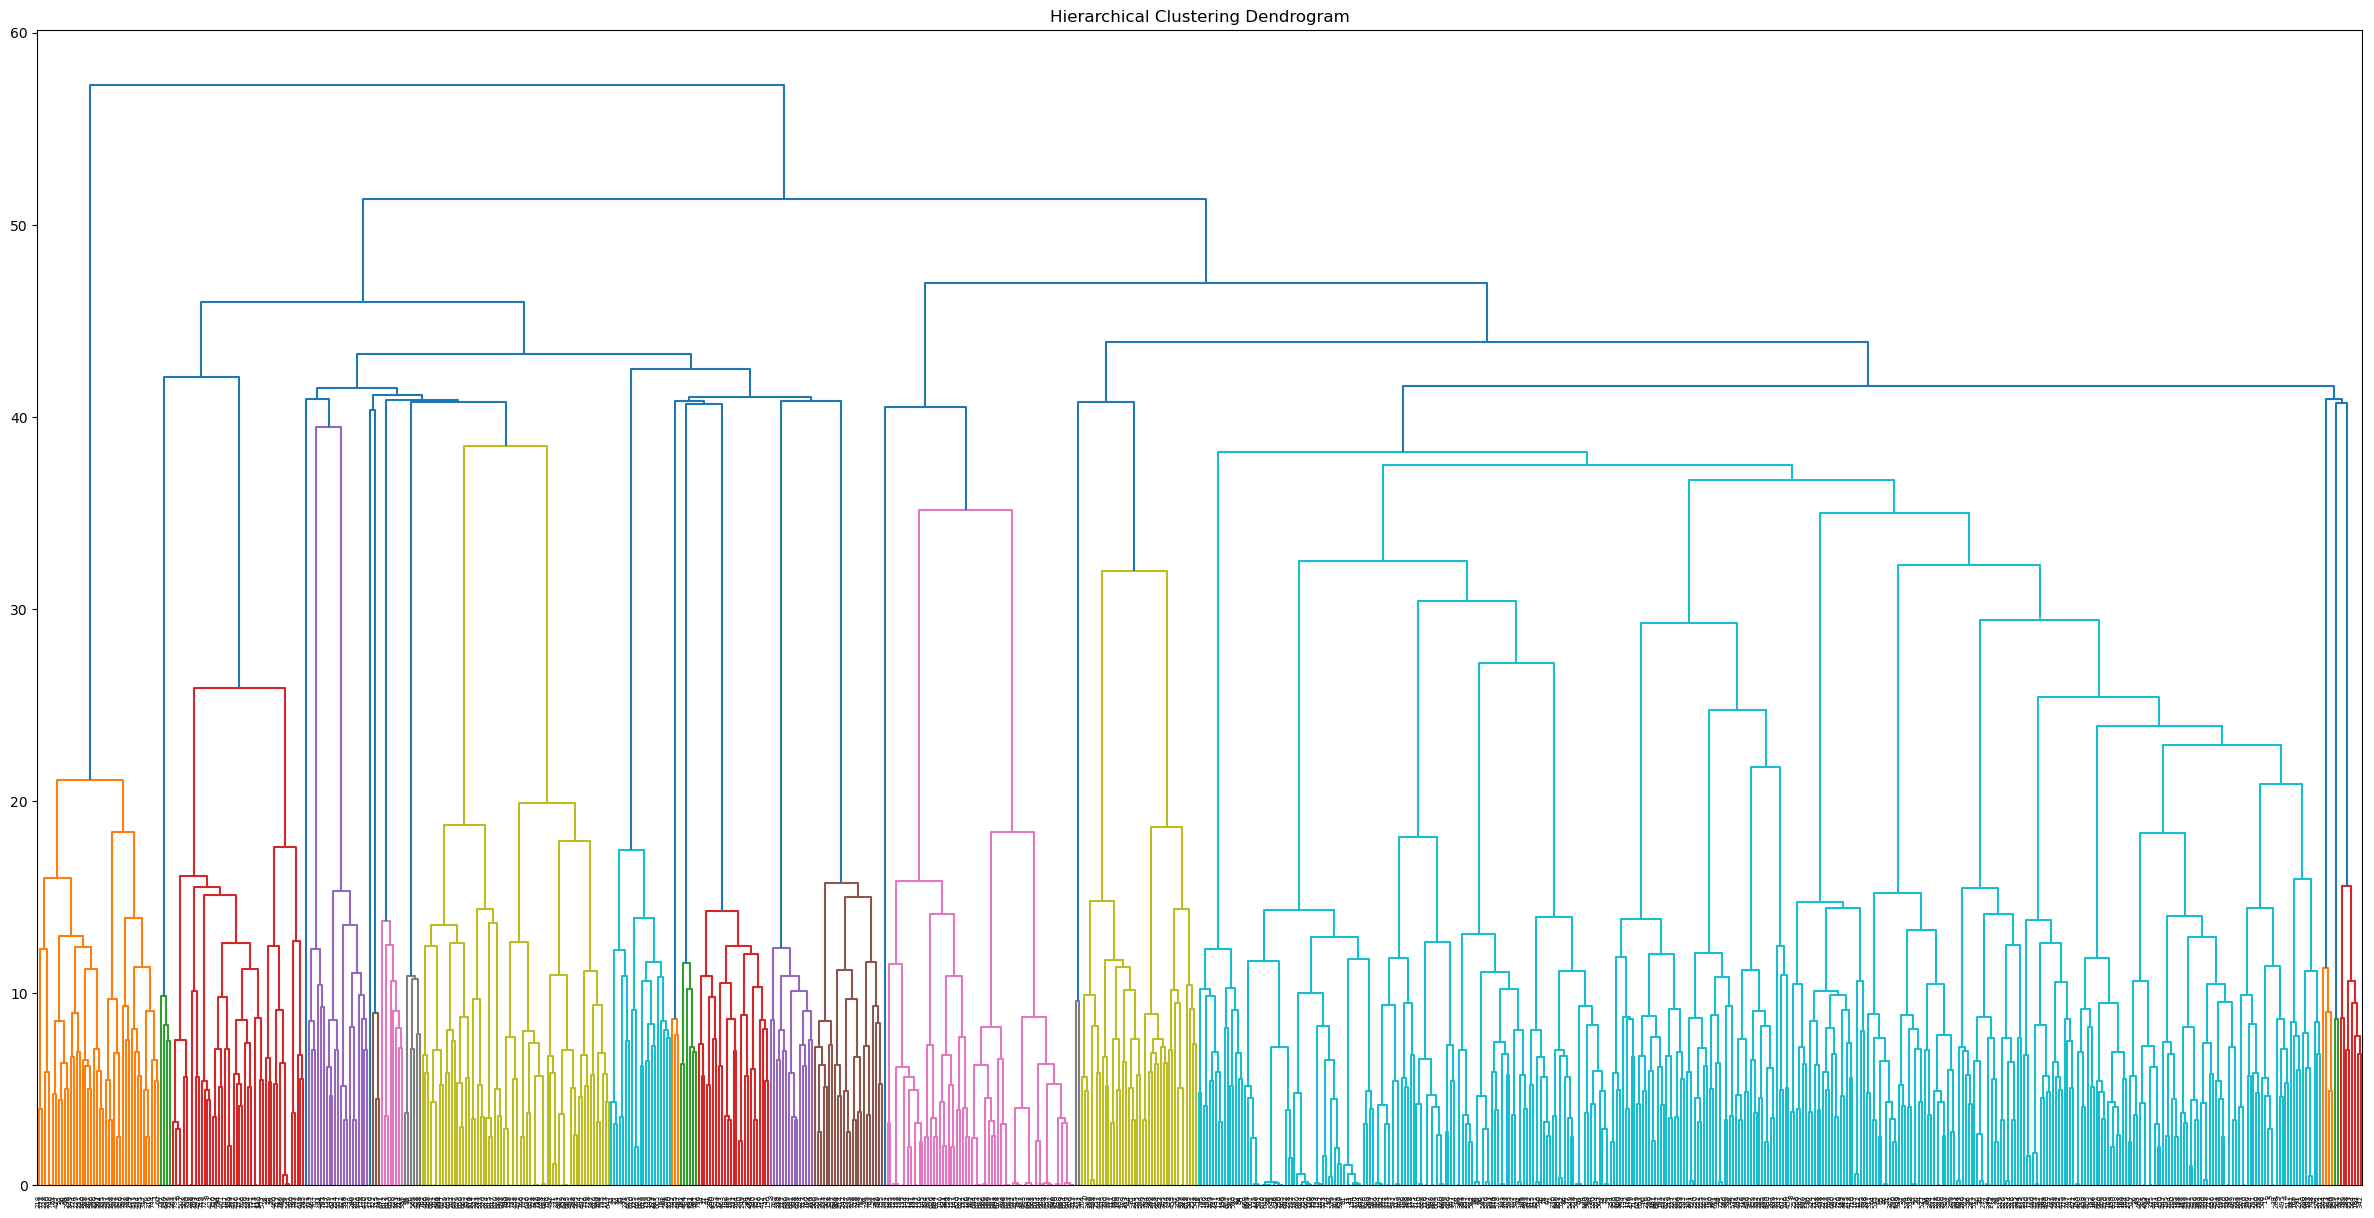

In [33]:
create_dendrogram(worker_st_scl, 'ward')

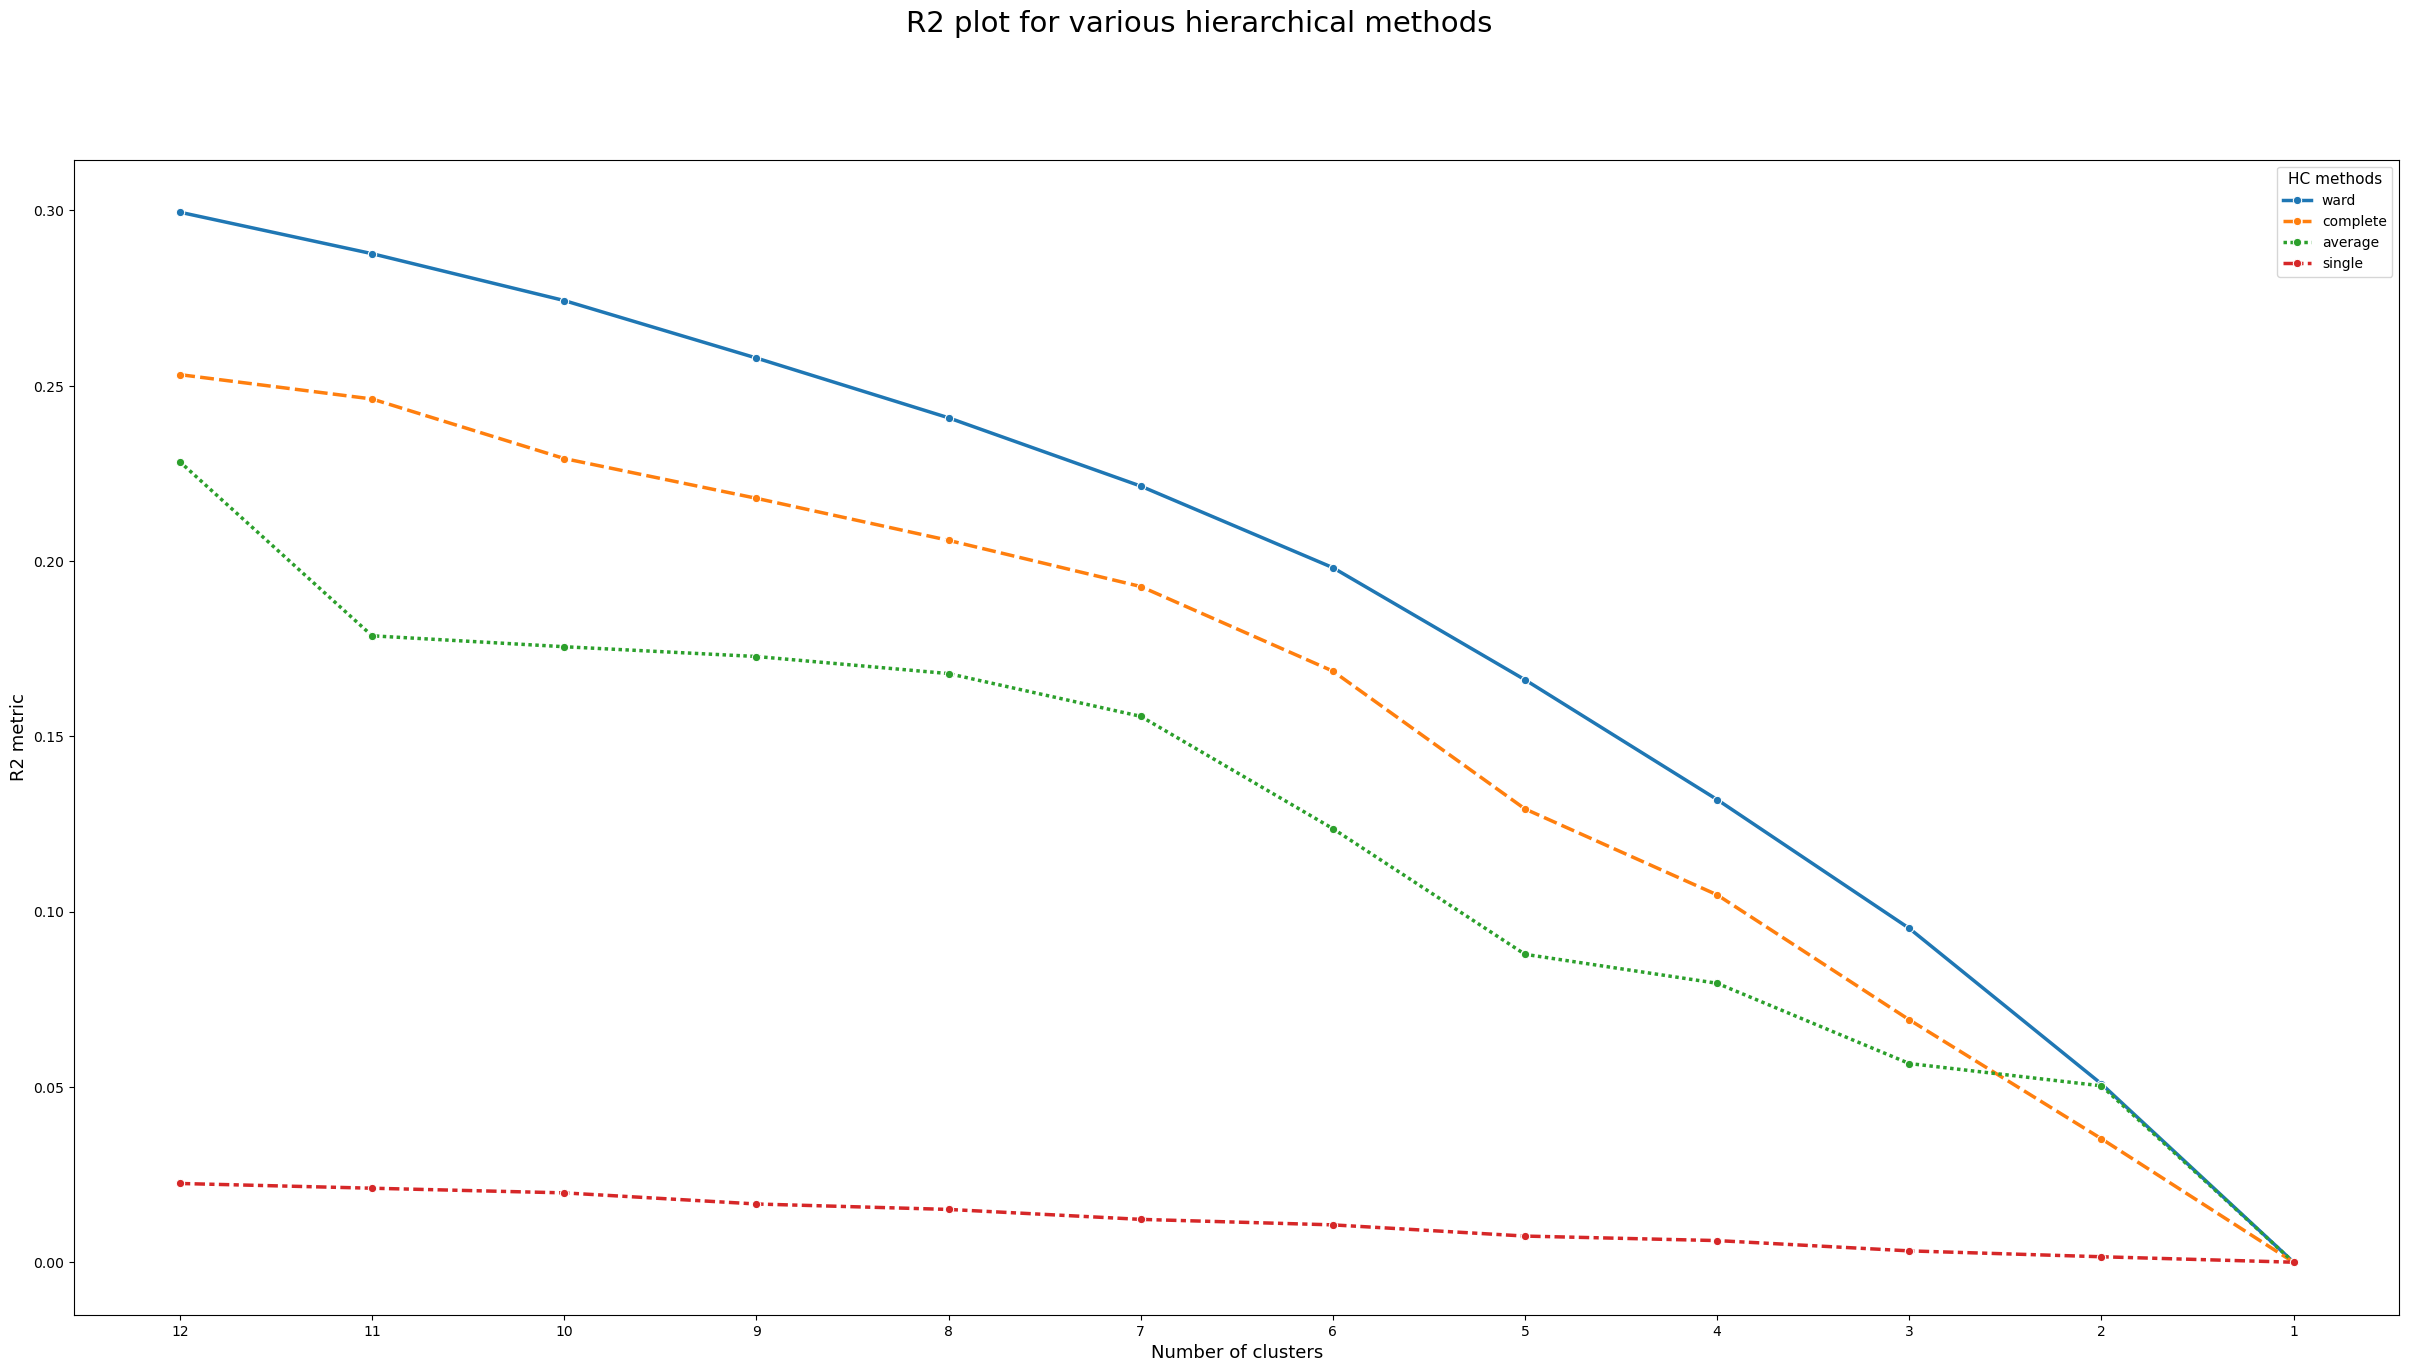

In [34]:
plot_r2_hc(worker_mm_scl, max_nclus=12)

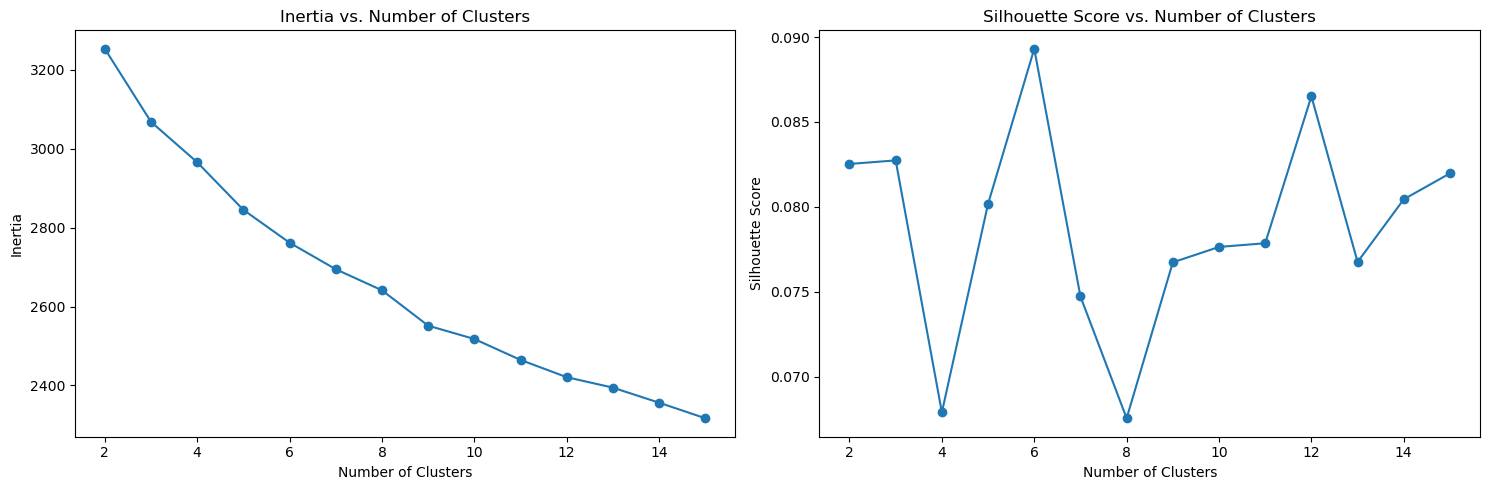

In [35]:
visualize_inertia_silhouette(worker_mm_scl)

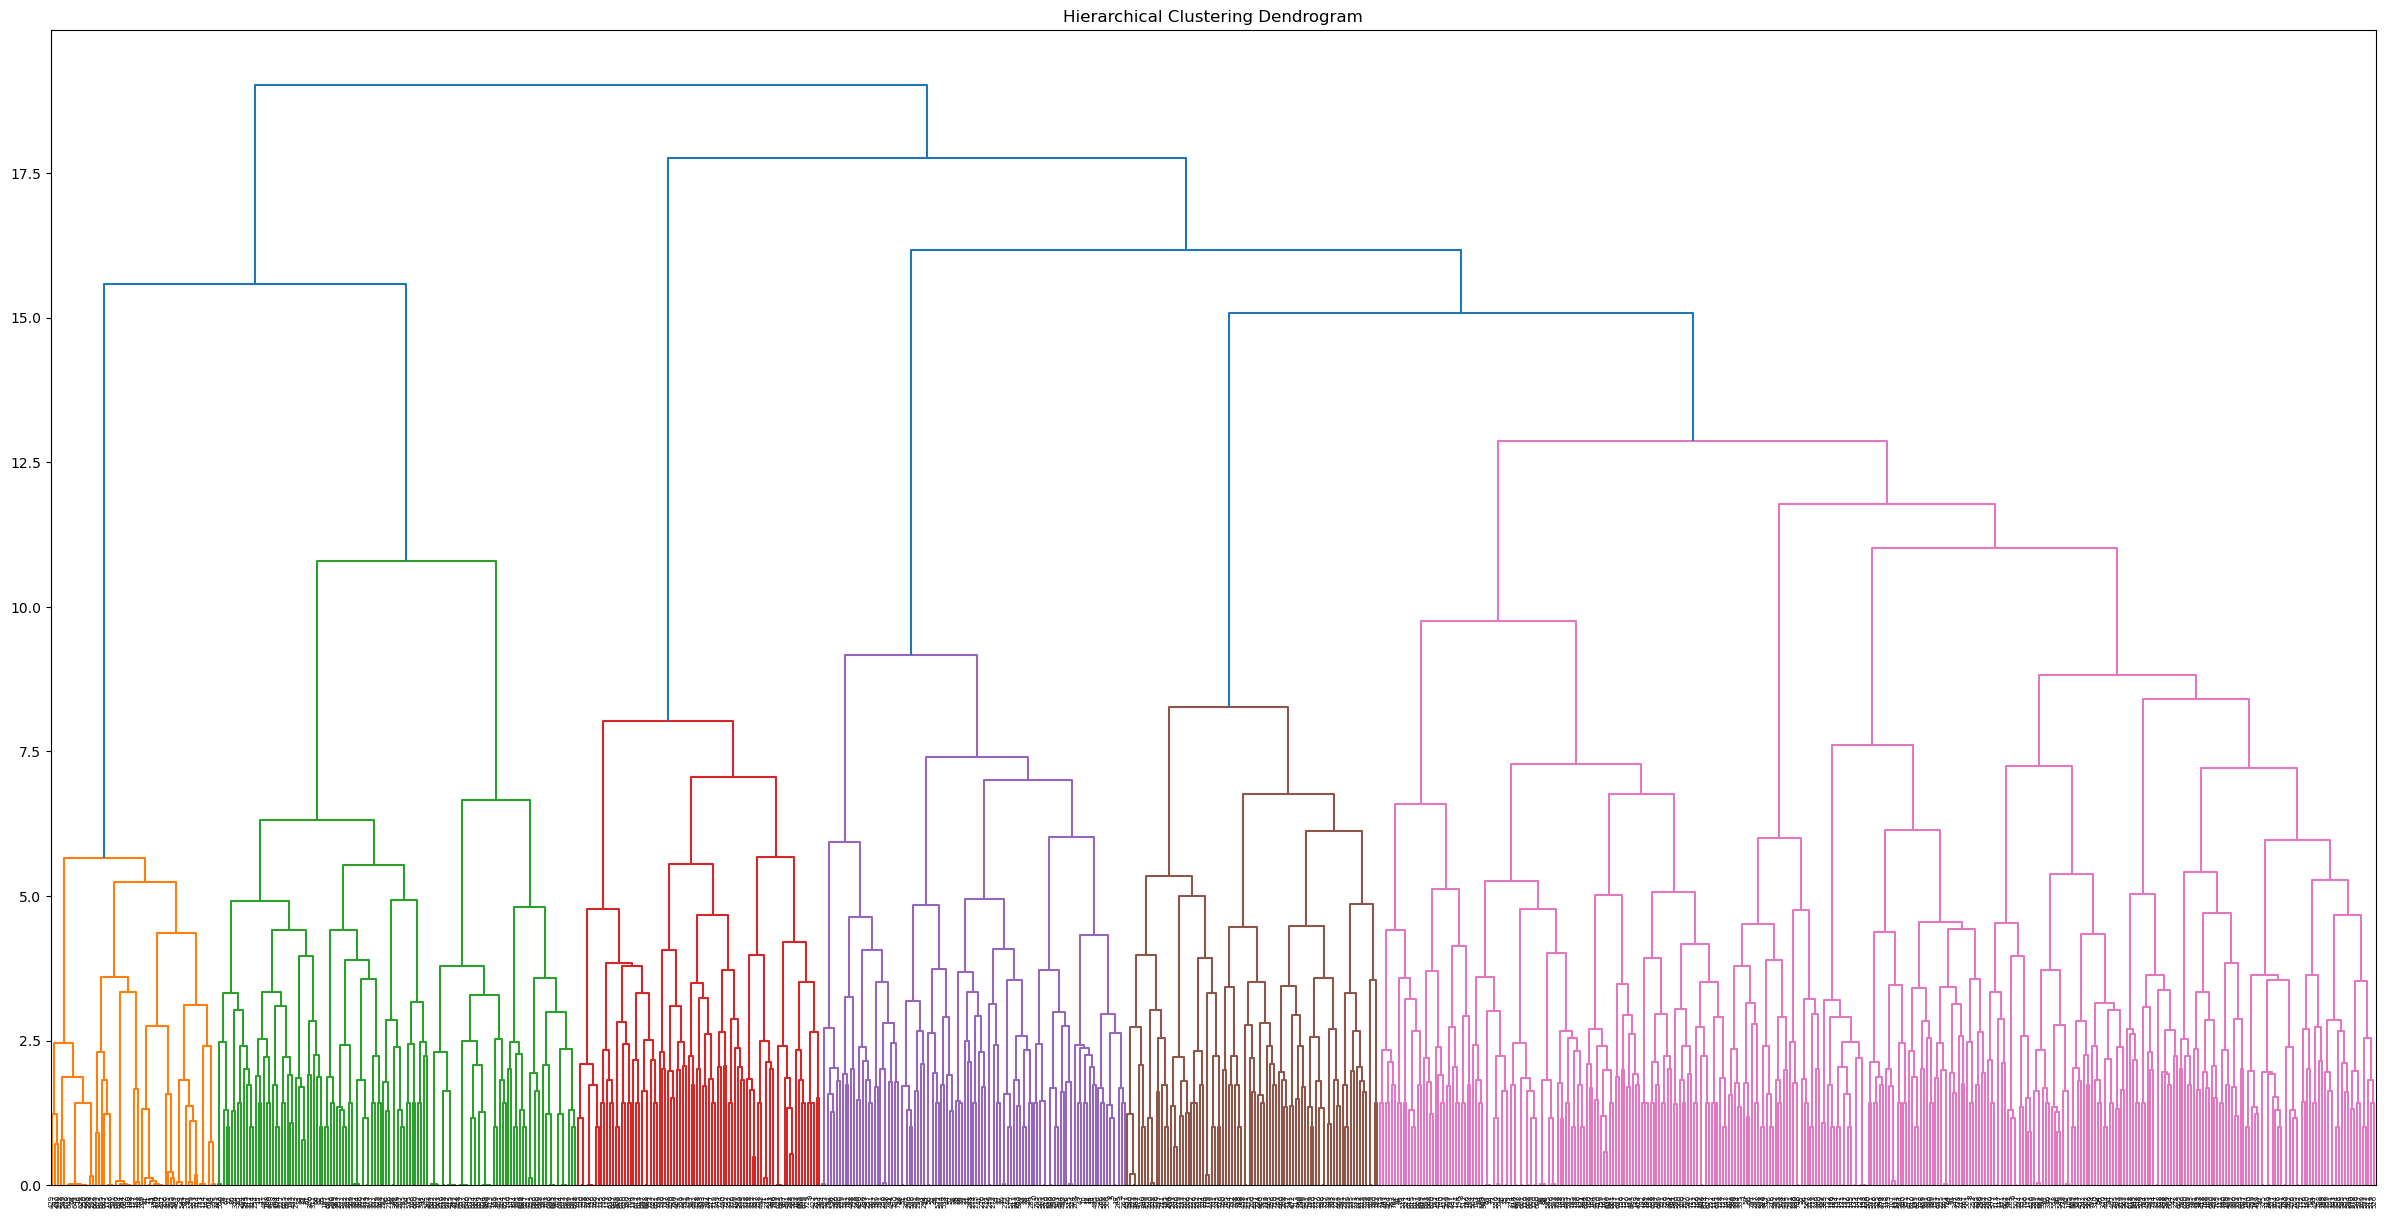

In [36]:
create_dendrogram(worker_mm_scl, 'ward')

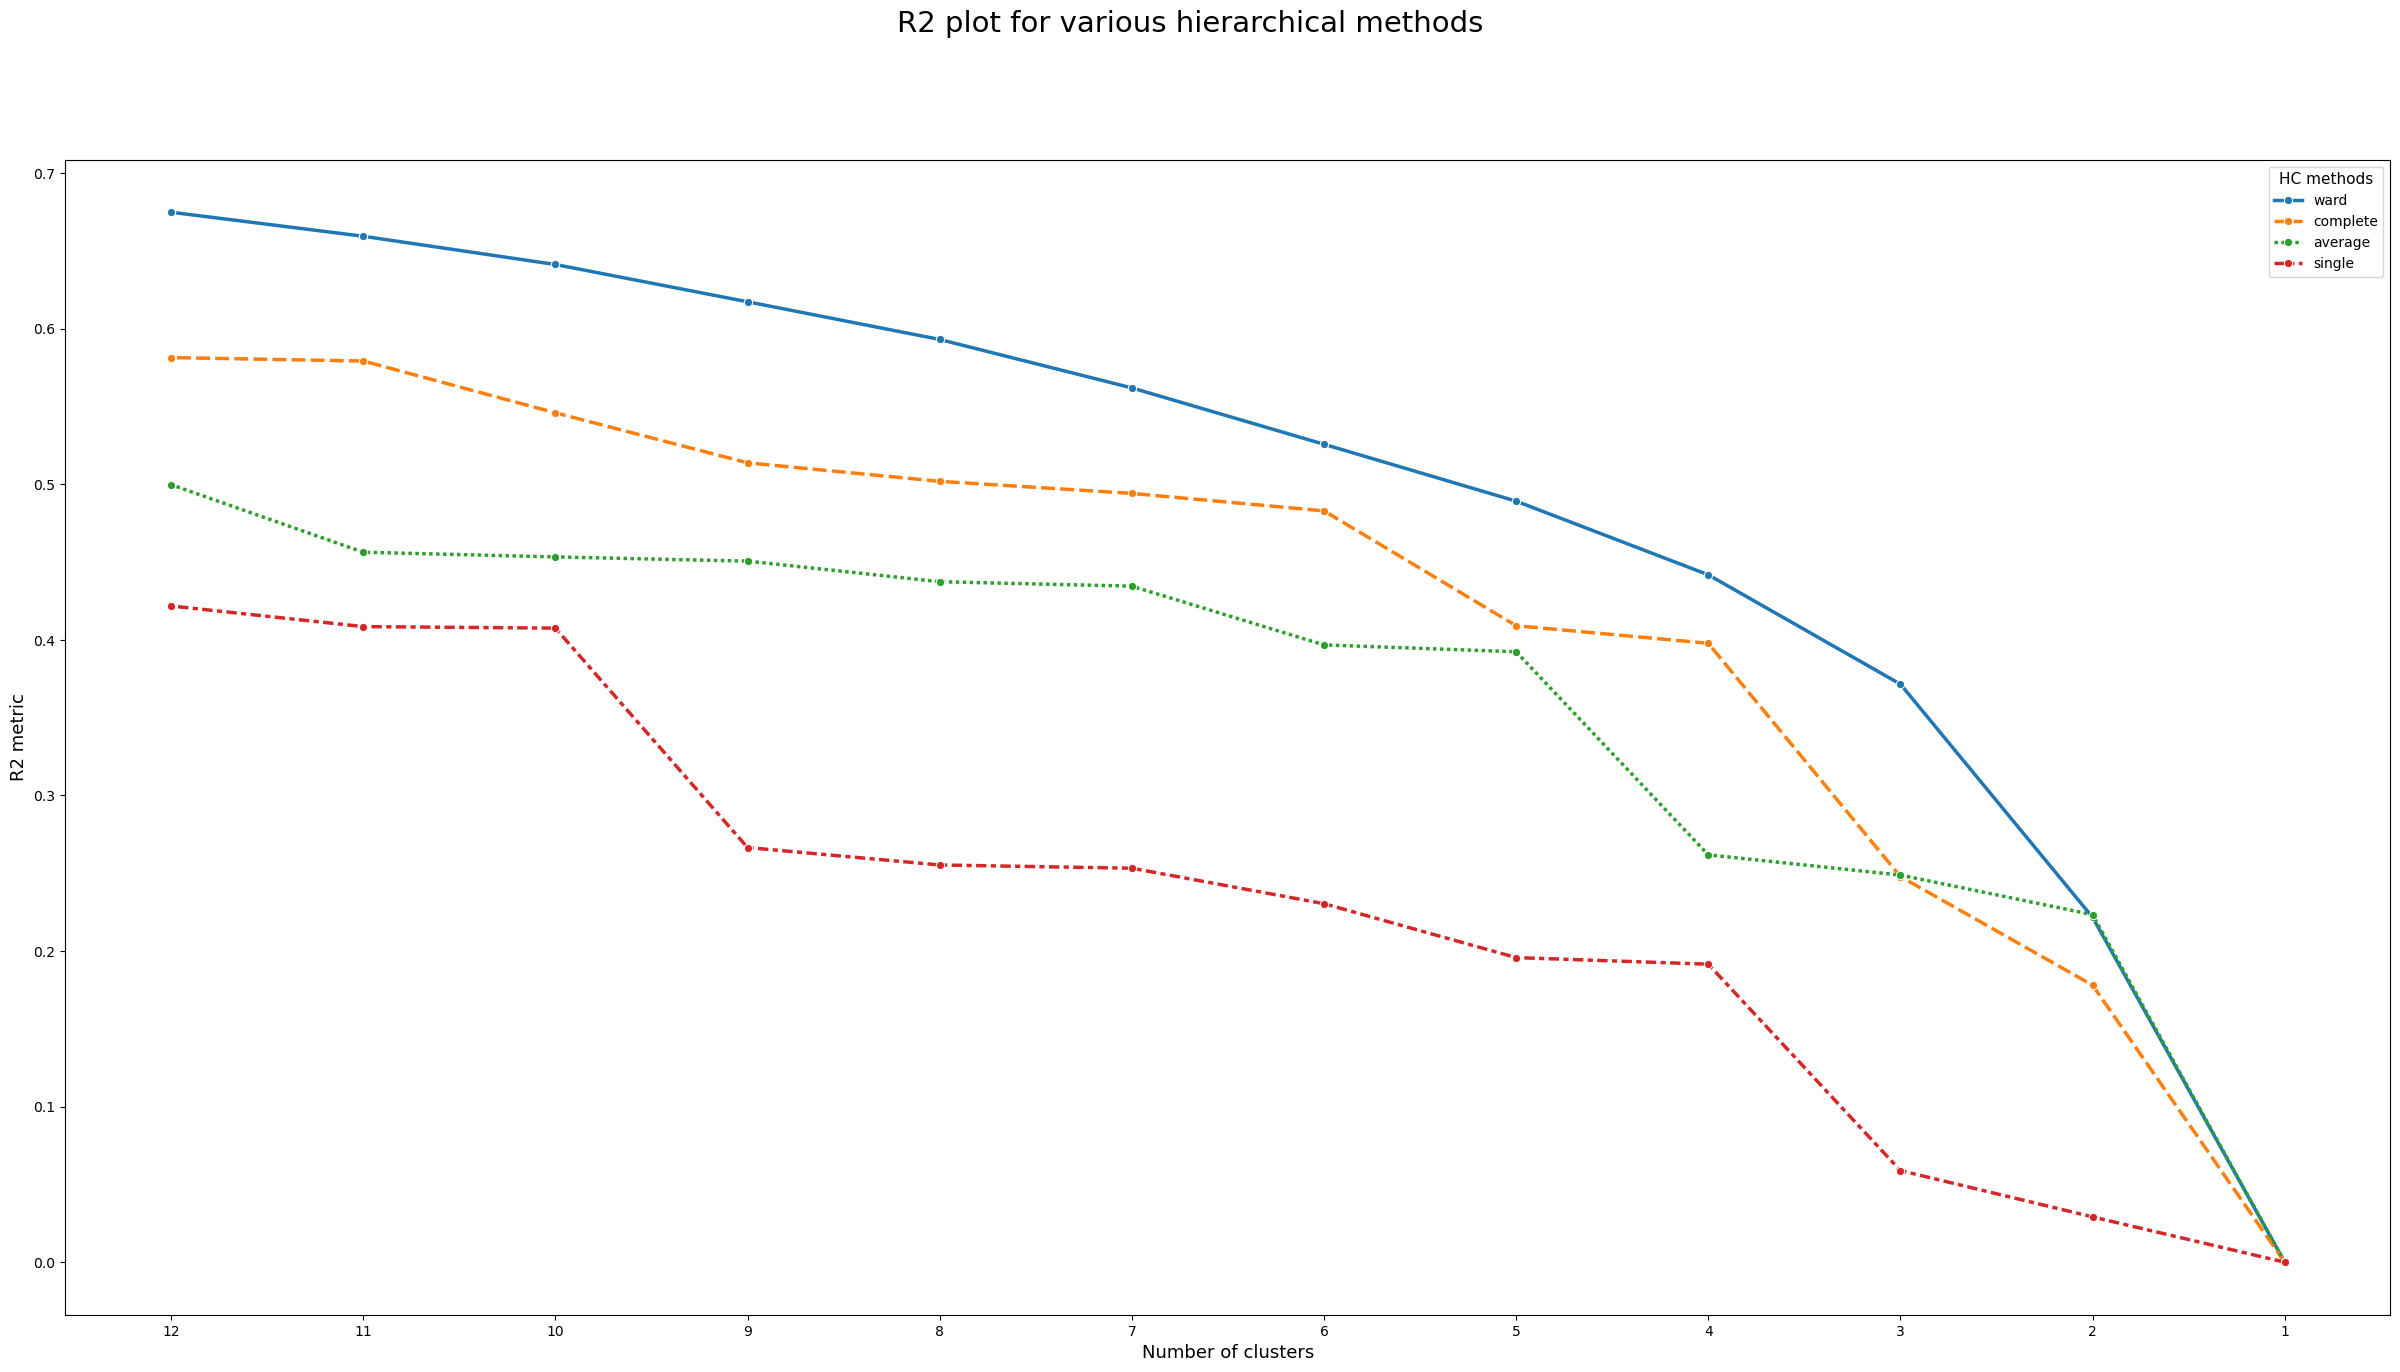

In [37]:
plot_r2_hc(worker_rb_scl, max_nclus=12)

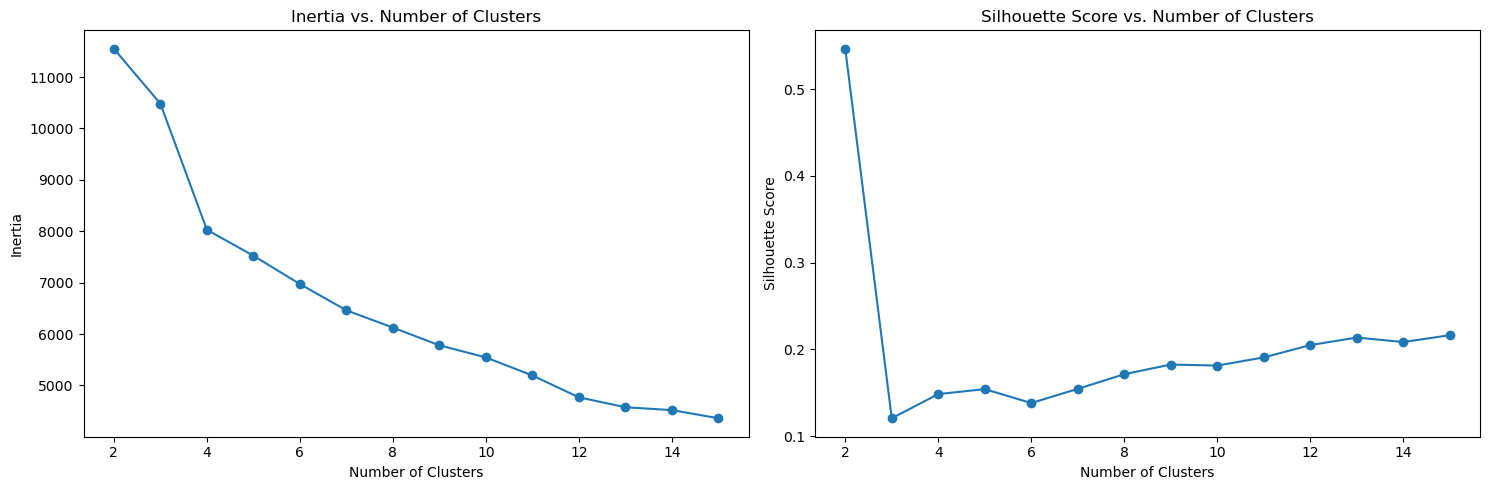

In [38]:
visualize_inertia_silhouette(worker_rb_scl)

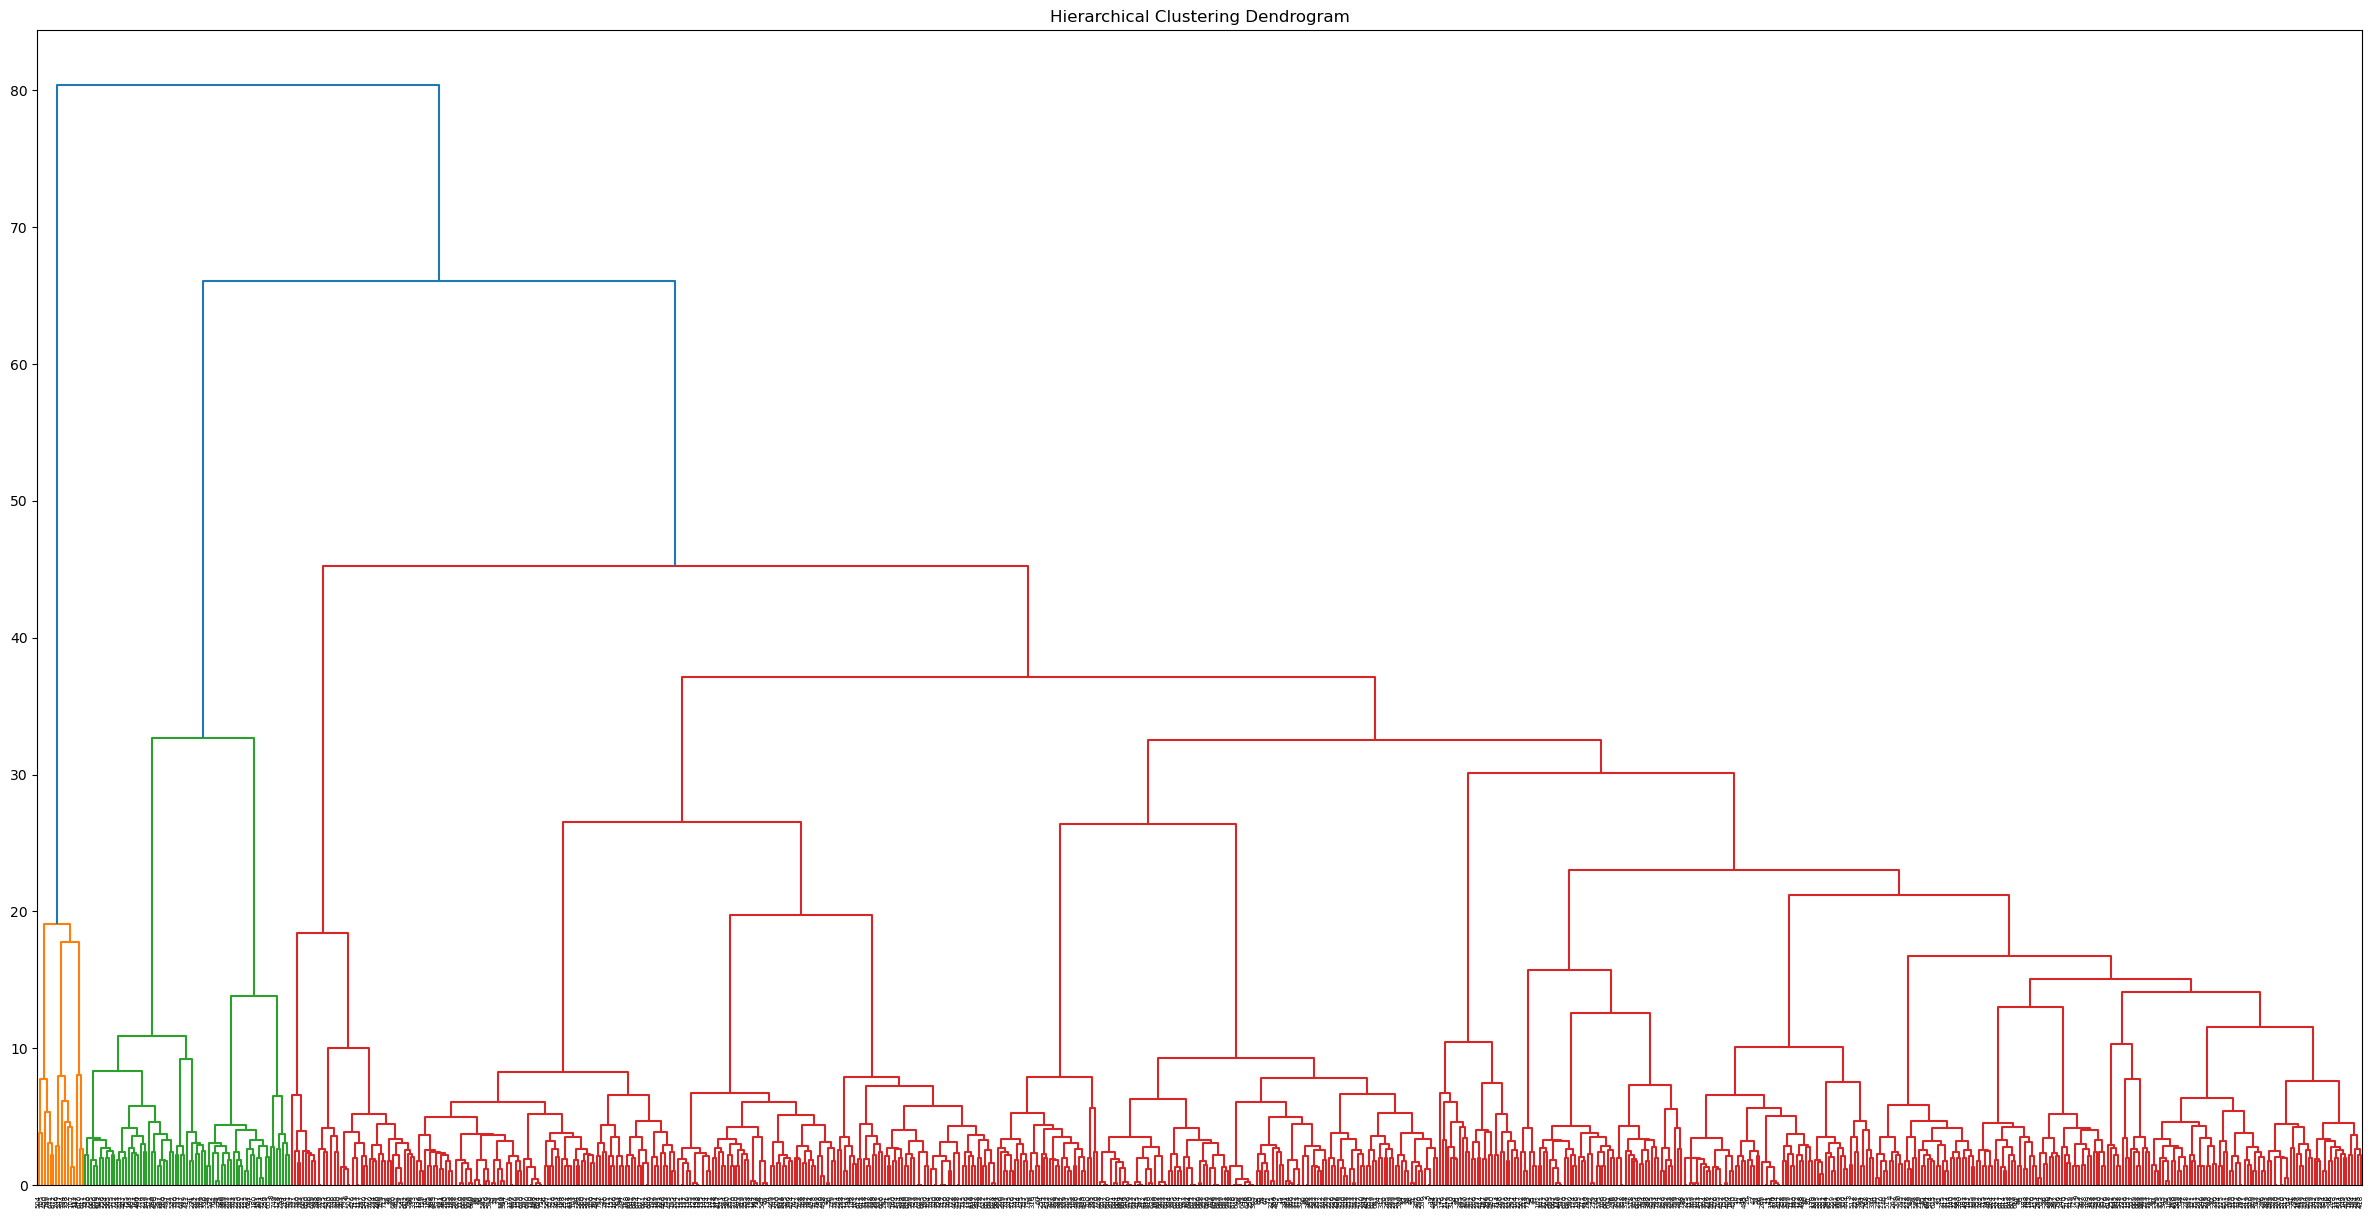

In [39]:
create_dendrogram(worker_rb_scl, 'ward')

In [40]:
worker['rb_ward9'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 9
    ).fit_predict(worker_rb_scl)

In [41]:
calculate_group_means(worker, 'rb_ward9')

rb_ward9,0,1,2,3,4,5,6,7,8
Age,40.710526,39.600000,33.309091,30.325581,41.5625,29.571429,34.0,36.607143,28.444444
Transportation expense,164.953947,261.803448,148.818182,334.697674,193.8125,261.857143,155.0,258.142857,221.800000
Distance from Residence to Work,42.276316,29.210345,19.018182,50.372093,16.7500,17.380952,12.0,34.785714,26.266667
Service time,18.078947,13.558621,9.372727,4.348837,13.7500,6.714286,14.0,13.750000,9.355556
Years until retirement,24.289474,25.451724,31.690909,34.674419,23.4375,34.190476,31.0,28.392857,36.555556
...,...,...,...,...,...,...,...,...,...
bmi_category_Obesity Class I,0.986842,0.234483,0.000000,0.023256,0.2500,0.000000,0.0,0.428571,0.000000
bmi_category_Obesity Class II,0.000000,0.093103,0.000000,0.000000,0.0000,0.000000,0.0,0.000000,0.000000
bmi_category_Overweight,0.013158,0.272414,0.500000,0.604651,0.4375,0.833333,1.0,0.285714,0.088889
no_kmeans6,2.539474,2.310345,2.000000,2.534884,2.6250,3.261905,4.0,1.785714,4.822222


In [47]:
umap_object = umap.UMAP(n_neighbors = 30, min_dist = 0.15, random_state = 42)

In [48]:
umap_embedding = umap_object.fit_transform(worker_no_scl)

/Users/franciscogomes/anaconda3/envs/data_mining/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/franciscogomes/Desktop/Faculdade/Master/Data Mining/Project/reasons_for_absenteeism/code/modeling_pipeline.py:180: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=cmap(norm(i)), label=label) for i, label in enumerate(labels)]


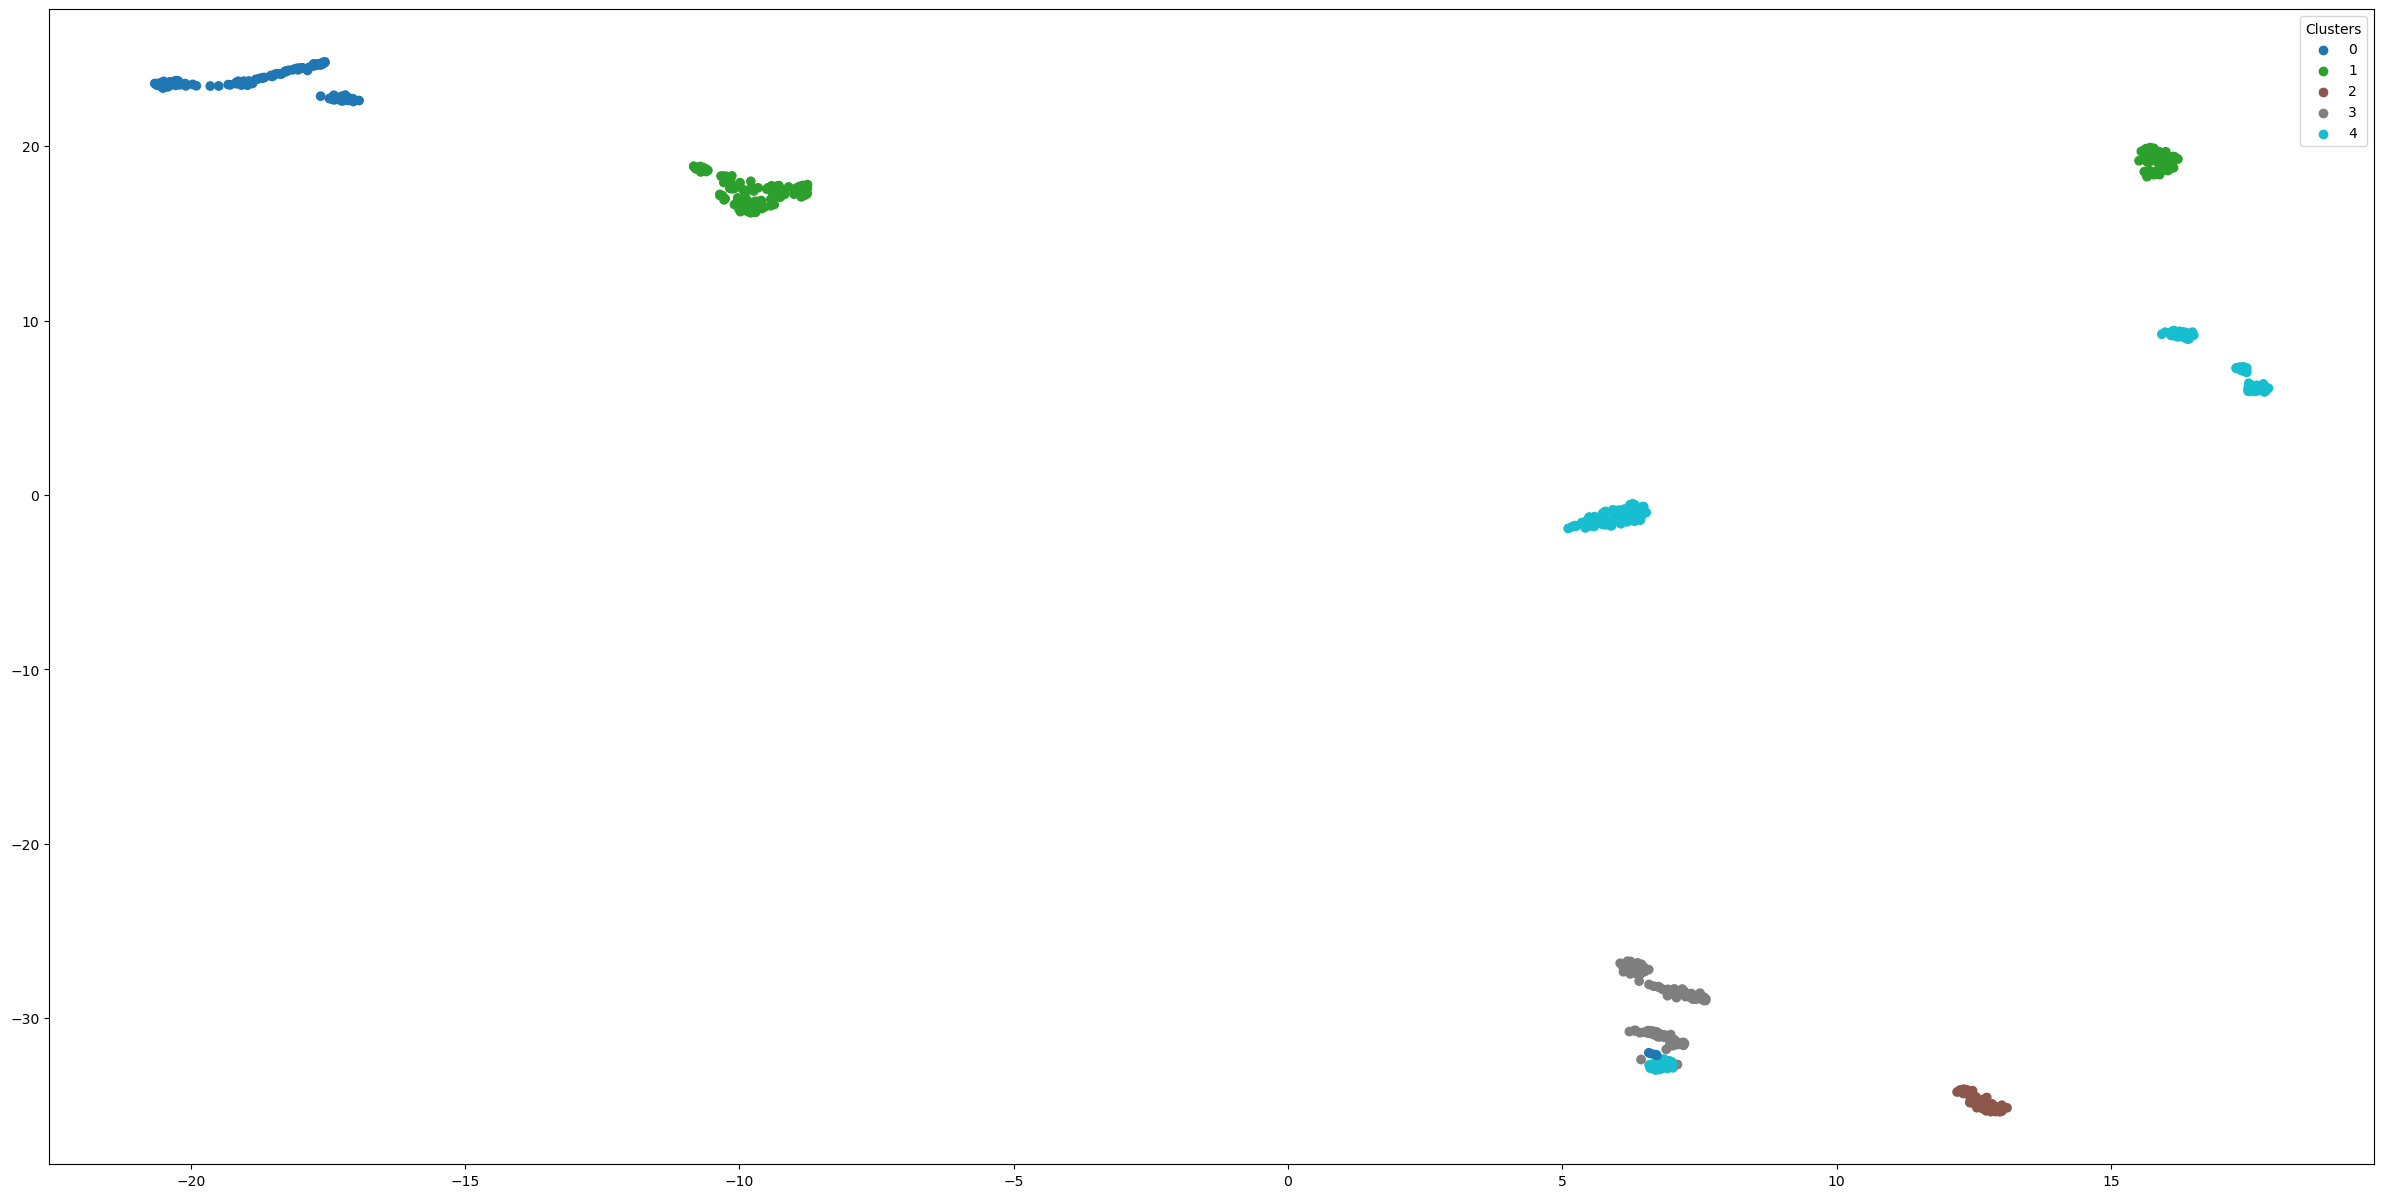

In [49]:
plot_dimensionality_reduction_results(umap_embedding, worker['no_ward5'])